# Dataset de Imágenes

## Procesamiento Dataset

In [63]:
import os
import random
from sklearn.model_selection import train_test_split

base_path = r"D:\DATASETS\BIOSCAN-30k\data"

# Recopilar todas las rutas
all_image_paths = []
for i in range(15):
    folder = os.path.join(base_path, f"data_{i}")
    for fname in os.listdir(folder):
        if fname.lower().endswith('.jpg'):
            all_image_paths.append(os.path.join(folder, fname))

print(f"Total imágenes: {len(all_image_paths)}")

# Mezclar y dividir
random.seed(42)
random.shuffle(all_image_paths)

train_paths, test_paths = train_test_split(all_image_paths, test_size=0.2, random_state=42)

print(f"Train: {len(train_paths)}")
print(f"Test:  {len(test_paths)}")

Total imágenes: 30000
Train: 24000
Test:  6000


In [64]:
import numpy as np
from PIL import Image

def load_images_in_blocks(paths, img_size=(128, 128), block_size=1000):
    """
    Generador que carga imágenes en bloques.
    Cada llamada devuelve un bloque de `block_size` imágenes como array numpy.
    """
    for start in range(0, len(paths), block_size):
        block_paths = paths[start:start + block_size]
        block_images = []

        for path in block_paths:
            try:
                img = Image.open(path).convert('RGB')   # Abre como RGB (3 canales)
                img = img.resize(img_size)              # Redimensiona a (64, 64)
                arr = np.array(img) / 255.0            # Convierte a numpy, shape: (64, 64, 3)
                block_images.append(arr.flatten())     # Aplana → shape: (12288,)
            except Exception as e:
                print(f"Error leyendo {path}: {e}")

        yield np.array(block_images), block_paths[: len(block_images)]
        print(f"  Bloque cargado: [{start} - {start + len(block_images)}]")

In [65]:
from sklearn.decomposition import IncrementalPCA
from tqdm import tqdm

ipca = IncrementalPCA(n_components=128, batch_size=1000)

muestra_fit = train_paths[:8000]

for block, _ in tqdm(load_images_in_blocks(muestra_fit, img_size=(64,64), block_size=1000),
                     total=8, desc="Entrenando PCA"):
    ipca.partial_fit(block)

print(f"Varianza conservada: {np.sum(ipca.explained_variance_ratio_)*100:.1f}%")

X_train_pca = []
for block, _ in tqdm(load_images_in_blocks(train_paths, img_size=(64,64), block_size=1000),
                     total=len(train_paths)//1000 + 1, desc="Transformando train"):
    X_train_pca.append(ipca.transform(block))

X_train_pca = np.vstack(X_train_pca)
print(f"Shape final X_train: {X_train_pca.shape}")  # (n_imgs, 128)

Entrenando PCA:  12%|█▎        | 1/8 [00:08<01:01,  8.82s/it]

  Bloque cargado: [0 - 1000]


Entrenando PCA:  25%|██▌       | 2/8 [00:19<00:58,  9.68s/it]

  Bloque cargado: [1000 - 2000]


Entrenando PCA:  38%|███▊      | 3/8 [00:26<00:42,  8.42s/it]

...

  Bloque cargado: [21000 - 22000]


Transformando train:  92%|█████████▏| 23/25 [01:05<00:04,  2.04s/it]

  Bloque cargado: [22000 - 23000]


Transformando train:  96%|█████████▌| 24/25 [01:07<00:02,  2.79s/it]

  Bloque cargado: [23000 - 24000]
Shape final X_train: (24000, 128)


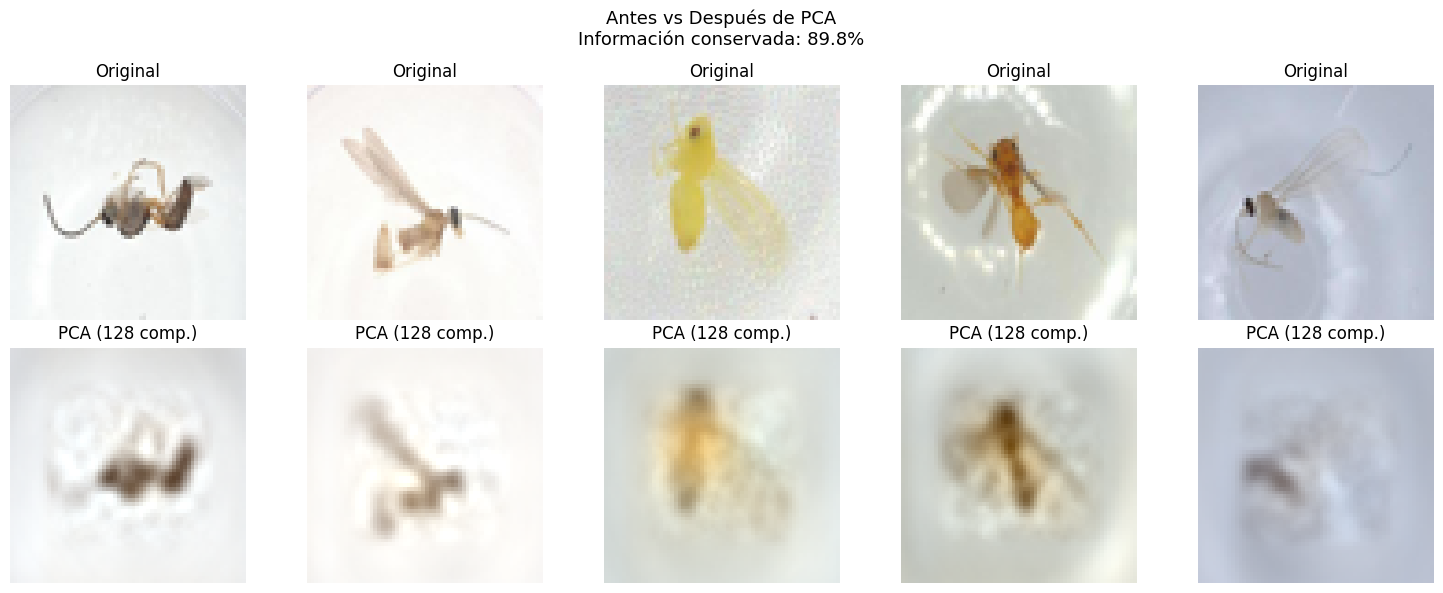

In [66]:
import matplotlib.pyplot as plt
import numpy as np

def mostrar_antes_despues(train_paths, ipca, img_size=(64, 64), n_imagenes=5):
    """
    Muestra n imágenes originales vs su reconstrucción después de PCA
    """
    # Cargar solo las primeras n imágenes
    originales = []
    for path in train_paths[:n_imagenes]:
        img = Image.open(path).convert('RGB')
        img = img.resize(img_size)
        arr = np.array(img) / 255.0
        originales.append(arr)

    # Aplanar para PCA
    X_muestra = np.array([img.flatten() for img in originales])

    # Transformar y reconstruir
    X_reducido    = ipca.transform(X_muestra)       # (n, 64)
    X_reconstruido = ipca.inverse_transform(X_reducido)  # (n, 12288)

    # Recortar valores fuera de rango (puede pasar en reconstrucción)
    X_reconstruido = np.clip(X_reconstruido, 0, 1)

    # Reshape para visualizar
    imgs_reconstruidas = X_reconstruido.reshape(-1, img_size[0], img_size[1], 3)

    # Graficar
    fig, axes = plt.subplots(2, n_imagenes, figsize=(n_imagenes * 3, 6))

    for i in range(n_imagenes):
        # Fila 0: originales
        axes[0, i].imshow(originales[i])
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        # Fila 1: reconstruidas
        axes[1, i].imshow(imgs_reconstruidas[i])
        axes[1, i].set_title(f"PCA ({ipca.n_components} comp.)")
        axes[1, i].axis('off')

    plt.suptitle(f"Antes vs Después de PCA\nInformación conservada: {np.sum(ipca.explained_variance_ratio_)*100:.1f}%",
                 fontsize=13)
    plt.tight_layout()
    plt.show()

# Llamar después de hacer el fit del PCA
mostrar_antes_despues(train_paths, ipca, img_size=(64, 64), n_imagenes=5)

## Aprendizaje No Supervisado

In [67]:
from sklearn.cluster import MiniBatchKMeans
from tqdm import tqdm

k = 30
minibatch_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000)

total_bloques = len(train_paths) // 1000 + 1

for block, _ in tqdm(load_images_in_blocks(train_paths, img_size=(64,64), block_size=1000),
                     total=total_bloques, desc="Fit KMeans"):
    block_pca = ipca.transform(block)      
    minibatch_kmeans.partial_fit(block_pca) 

print("KMeans entrenado")

Fit KMeans:   4%|▍         | 1/25 [00:01<00:45,  1.91s/it]

  Bloque cargado: [0 - 1000]


Fit KMeans:   8%|▊         | 2/25 [00:03<00:44,  1.92s/it]

  Bloque cargado: [1000 - 2000]


Fit KMeans:  12%|█▏        | 3/25 [00:05<00:41,  1.90s/it]

...

  Bloque cargado: [21000 - 22000]


Fit KMeans:  92%|█████████▏| 23/25 [00:42<00:03,  1.87s/it]

  Bloque cargado: [22000 - 23000]


Fit KMeans:  96%|█████████▌| 24/25 [00:44<00:01,  1.86s/it]

  Bloque cargado: [23000 - 24000]
KMeans entrenado


In [68]:
# Necesitamos las distancias de cada imagen a cada centroide
# para encontrar la más representativa de cada cluster

all_distances = []  # distancias
all_indices   = []  # índices globales de cada imagen

idx_global = 0
for block, _ in tqdm(load_images_in_blocks(train_paths, img_size=(64,64), block_size=1000),
                     total=total_bloques, desc="Calculando distancias"):
    block_pca  = ipca.transform(block)
    distancias = minibatch_kmeans.transform(block_pca)  # (block_size, k)
    
    all_distances.append(distancias)
    all_indices.extend(range(idx_global, idx_global + len(block)))
    idx_global += len(block)

all_distances = np.vstack(all_distances)  # (n_total, 50)
print(f"Shape distancias: {all_distances.shape}")

Calculando distancias:   4%|▍         | 1/25 [00:01<00:45,  1.88s/it]

  Bloque cargado: [0 - 1000]


Calculando distancias:   8%|▊         | 2/25 [00:03<00:42,  1.83s/it]

  Bloque cargado: [1000 - 2000]


Calculando distancias:  12%|█▏        | 3/25 [00:05<00:39,  1.81s/it]

...

  Bloque cargado: [21000 - 22000]


Calculando distancias:  92%|█████████▏| 23/25 [00:41<00:03,  1.82s/it]

  Bloque cargado: [22000 - 23000]


Calculando distancias:  96%|█████████▌| 24/25 [00:43<00:01,  1.82s/it]

  Bloque cargado: [23000 - 24000]
Shape distancias: (24000, 30)


In [ ]:
# Índice global de la imagen más cercana a cada centroide
idxs_representantes = np.argmin(all_distances, axis=0)  # (30,)
print(f"Índices representantes: {idxs_representantes}")

Índices representantes: [23834  4847 15372  3043  9552  1472  5081  2576 13020  6452 13411 18772
 18704 21030 17313 10065 15039 11670 14895 13972    33  5198 17603  2712
 23787  7878 12643 21953  3190  3104]


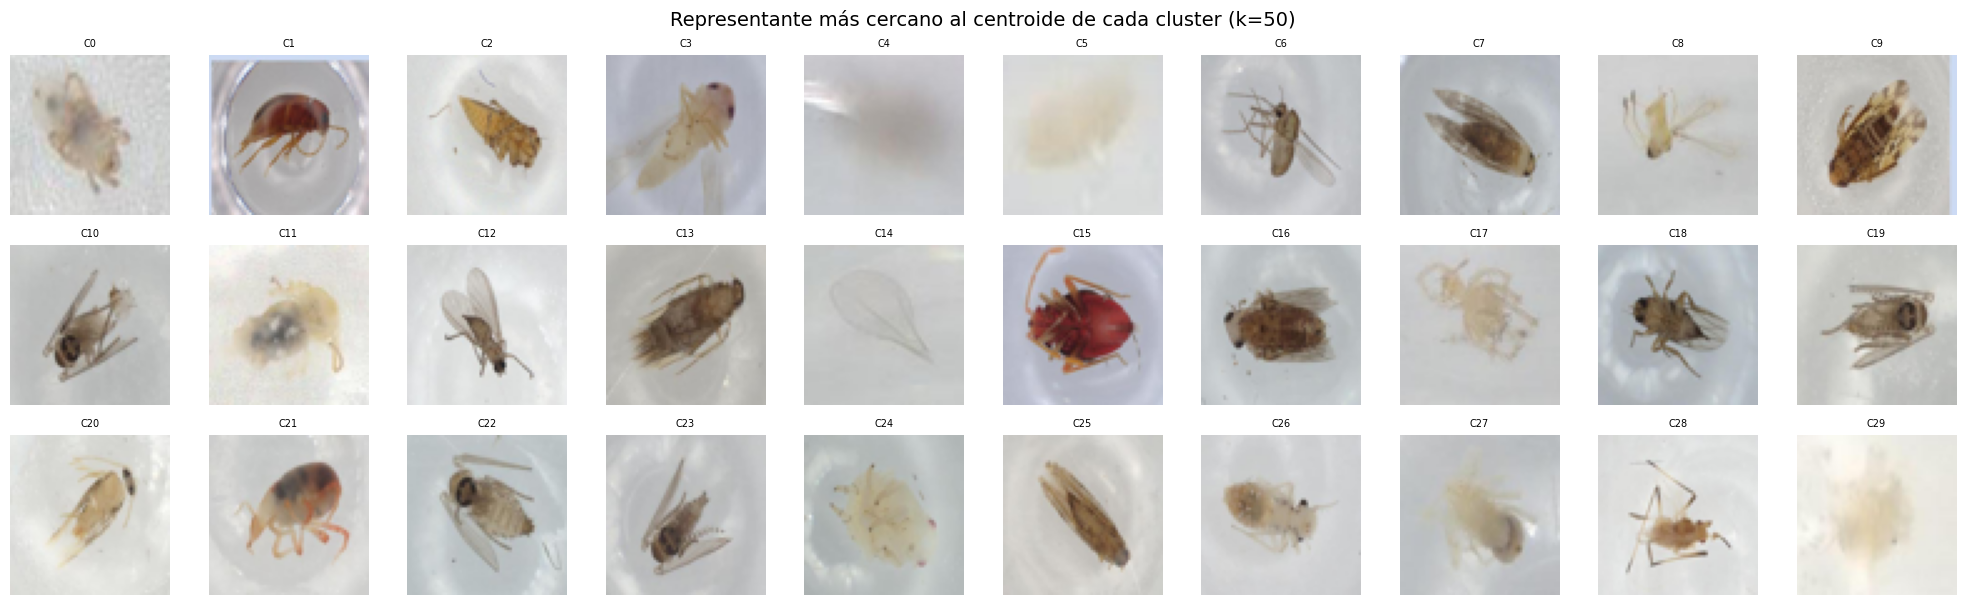

In [70]:
IMG_SIZE = (64, 64)

representative_imgs = []
for idx in idxs_representantes:
    path = train_paths[idx]
    img  = Image.open(path).convert('RGB').resize(IMG_SIZE)
    representative_imgs.append(np.array(img))

# Visualizar
plt.figure(figsize=(20, 10))
for i, img in enumerate(representative_imgs):
    plt.subplot(5, 10, i + 1)
    plt.imshow(img)
    plt.title(f"C{i}", fontsize=7)
    plt.axis('off')

plt.suptitle("Representante más cercano al centroide de cada cluster (k=50)", fontsize=14)
plt.tight_layout()
plt.show()

In [76]:
# Aquí las etiquetas se colocan manualmente mirando las imágenes


y_representative = np.array([
    0,  1,  2,  3,  4,  5,  6,  7,  8,  9,   # clusters 0-9
    10, 11, 12, 13, 14, 15, 16, 17, 18, 19,   # clusters 10-19
    20, 21, 22, 23, 24, 25, 26, 27, 28, 29,   # clusters 20-29
])

print(f"Etiquetas asignadas: {len(y_representative)} clusters")

Etiquetas asignadas: 30 clusters


In [77]:
# Cargar y transformar solo las 50 imágenes representativas
X_representative_pca = []

for idx in idxs_representantes:
    path = train_paths[idx]
    img  = Image.open(path).convert('RGB').resize((64, 64))
    arr  = np.array(img) / 255.0
    X_representative_pca.append(arr.flatten())

X_representative_pca = np.array(X_representative_pca)          # (50, 12288)
X_representative_pca = ipca.transform(X_representative_pca)    # (50, 64)

print(f"Shape representantes: {X_representative_pca.shape}")   # (50, 64)

Shape representantes: (30, 128)


In [78]:
# Red neural MLP para clasificación supervisada

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ── Dispositivo ───────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

# ── Arquitectura MLP ──────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, output_dim):
        super(MLP, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.red(x)

# input=128 (PCA), hidden=128,64, output=30 (clusters)
modelo = MLP(input_dim=128, hidden1=128, hidden2=64, output_dim=k).to(device)
print(modelo)

Usando: cuda
MLP(
  (red): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=30, bias=True)
  )
)


In [79]:
# Convertir a tensores
X_rep_tensor = torch.tensor(X_representative_pca, dtype=torch.float32).to(device)
y_rep_tensor  = torch.tensor(y_representative, dtype=torch.long).to(device)

criterio  = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)

# Entrenar
N_EPOCHS = 200  # más epochs porque son pocos datos (50 imgs)

modelo.train()
for epoch in range(N_EPOCHS):
    optimizador.zero_grad()
    salida = modelo(X_rep_tensor)
    loss   = criterio(salida, y_rep_tensor)
    loss.backward()
    optimizador.step()

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} | Loss: {loss.item():.4f}")

print("MLP entrenado con 30 representantes")

Epoch 30/200 | Loss: 1.8227
Epoch 60/200 | Loss: 0.2241
Epoch 90/200 | Loss: 0.0269
Epoch 120/200 | Loss: 0.0109
Epoch 150/200 | Loss: 0.0068
Epoch 180/200 | Loss: 0.0047
MLP entrenado con 30 representantes


In [80]:
# Necesitas los labels de KMeans para TODAS las imágenes de train

all_labels = []

for block, _ in tqdm(load_images_in_blocks(train_paths, img_size=(64,64), block_size=1000),
                     total=len(train_paths)//1000 + 1, desc="Obteniendo clusters"):
    block_pca = ipca.transform(block)
    labels    = minibatch_kmeans.predict(block_pca)  # cluster de cada imagen
    all_labels.extend(labels)

all_labels = np.array(all_labels)

# Propagar etiqueta del representante a todo su cluster
y_train_propagated = np.array([y_representative[l] for l in all_labels])

print(f"y_train_propagated shape: {y_train_propagated.shape}")
print(f"Distribución de clases: {np.unique(y_train_propagated, return_counts=True)}")

Obteniendo clusters:   4%|▍         | 1/25 [00:02<00:48,  2.03s/it]

  Bloque cargado: [0 - 1000]


Obteniendo clusters:   8%|▊         | 2/25 [00:03<00:45,  1.97s/it]

  Bloque cargado: [1000 - 2000]


Obteniendo clusters:  12%|█▏        | 3/25 [00:05<00:43,  2.00s/it]

...

  Bloque cargado: [21000 - 22000]


Obteniendo clusters:  92%|█████████▏| 23/25 [00:44<00:04,  2.08s/it]

  Bloque cargado: [22000 - 23000]


Obteniendo clusters:  96%|█████████▌| 24/25 [00:46<00:01,  1.95s/it]

  Bloque cargado: [23000 - 24000]
y_train_propagated shape: (24000,)
Distribución de clases: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]), array([ 734,  441,  335,  775, 1071, 1316,  806,  788, 1184,  427,  852,
        404,  420,  434, 2425,  422,  382, 1224,  550,  775,  663,  574,
        825,  869, 1772,  281,  723, 1006,  501, 1021]))


In [81]:
from tqdm import tqdm

criterio    = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.001)
N_EPOCHS    = 20

modelo.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0
    total_bloques = len(train_paths) // 1000 + 1

    for bloque_idx, (block, _) in enumerate(
        tqdm(load_images_in_blocks(train_paths, img_size=(64,64), block_size=1000),
             total=total_bloques, desc=f"Epoch {epoch+1}/{N_EPOCHS}")):

        # PCA + convertir a tensor
        block_pca = ipca.transform(block)
        X_batch   = torch.tensor(block_pca, dtype=torch.float32).to(device)

        # Etiquetas propagadas del bloque
        inicio   = bloque_idx * 1000
        fin      = inicio + len(block)
        y_batch  = torch.tensor(
                       y_train_propagated[inicio:fin],
                       dtype=torch.long).to(device)

        # Forward + backward
        optimizador.zero_grad()
        salida = modelo(X_batch)
        loss   = criterio(salida, y_batch)
        loss.backward()
        optimizador.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss promedio: {epoch_loss/total_bloques:.4f}")

Epoch 1/20:   4%|▍         | 1/25 [00:01<00:45,  1.90s/it]

  Bloque cargado: [0 - 1000]


Epoch 1/20:   8%|▊         | 2/25 [00:03<00:43,  1.89s/it]

  Bloque cargado: [1000 - 2000]


Epoch 1/20:  12%|█▏        | 3/25 [00:05<00:41,  1.89s/it]

...

  Bloque cargado: [21000 - 22000]


Epoch 20/20:  92%|█████████▏| 23/25 [00:42<00:03,  1.87s/it]

  Bloque cargado: [22000 - 23000]


Epoch 20/20:  96%|█████████▌| 24/25 [00:44<00:01,  1.86s/it]

  Bloque cargado: [23000 - 24000]
Epoch 20 | Loss promedio: 0.1738


In [82]:
modelo.eval()
correctas = 0
total     = 0

with torch.no_grad():
    for block, _ in tqdm(load_images_in_blocks(test_paths, img_size=(64,64), block_size=1000),
                         total=len(test_paths)//1000 + 1, desc="Evaluando"):

        block_pca  = ipca.transform(block)
        X_batch    = torch.tensor(block_pca, dtype=torch.float32).to(device)

        # Etiquetas propagadas para test
        labels_cluster = minibatch_kmeans.predict(block_pca)
        y_batch        = torch.tensor(
                             np.array([y_representative[l] for l in labels_cluster]),
                             dtype=torch.long).to(device)

        salida     = modelo(X_batch)
        prediccion = torch.argmax(salida, dim=1)

        correctas += (prediccion == y_batch).sum().item()
        total     += len(y_batch)

print(f"Accuracy: {correctas/total*100:.2f}%")

Evaluando:  14%|█▍        | 1/7 [00:02<00:13,  2.25s/it]

  Bloque cargado: [0 - 1000]


Evaluando:  29%|██▊       | 2/7 [00:04<00:11,  2.22s/it]

  Bloque cargado: [1000 - 2000]


Evaluando:  43%|████▎     | 3/7 [00:06<00:08,  2.14s/it]

...

  Bloque cargado: [3000 - 4000]


Evaluando:  71%|███████▏  | 5/7 [00:10<00:04,  2.09s/it]

  Bloque cargado: [4000 - 5000]


Evaluando:  86%|████████▌ | 6/7 [00:12<00:02,  2.11s/it]

  Bloque cargado: [5000 - 6000]
Accuracy: 87.68%


Generando predicciones:  14%|█▍        | 1/7 [00:01<00:11,  1.89s/it]

  Bloque cargado: [0 - 1000]


Generando predicciones:  29%|██▊       | 2/7 [00:04<00:10,  2.04s/it]

  Bloque cargado: [1000 - 2000]


Generando predicciones:  43%|████▎     | 3/7 [00:05<00:08,  2.01s/it]

...

  Bloque cargado: [3000 - 4000]


Generando predicciones:  71%|███████▏  | 5/7 [00:09<00:03,  2.00s/it]

  Bloque cargado: [4000 - 5000]


Generando predicciones:  86%|████████▌ | 6/7 [00:11<00:01,  1.97s/it]


  Bloque cargado: [5000 - 6000]


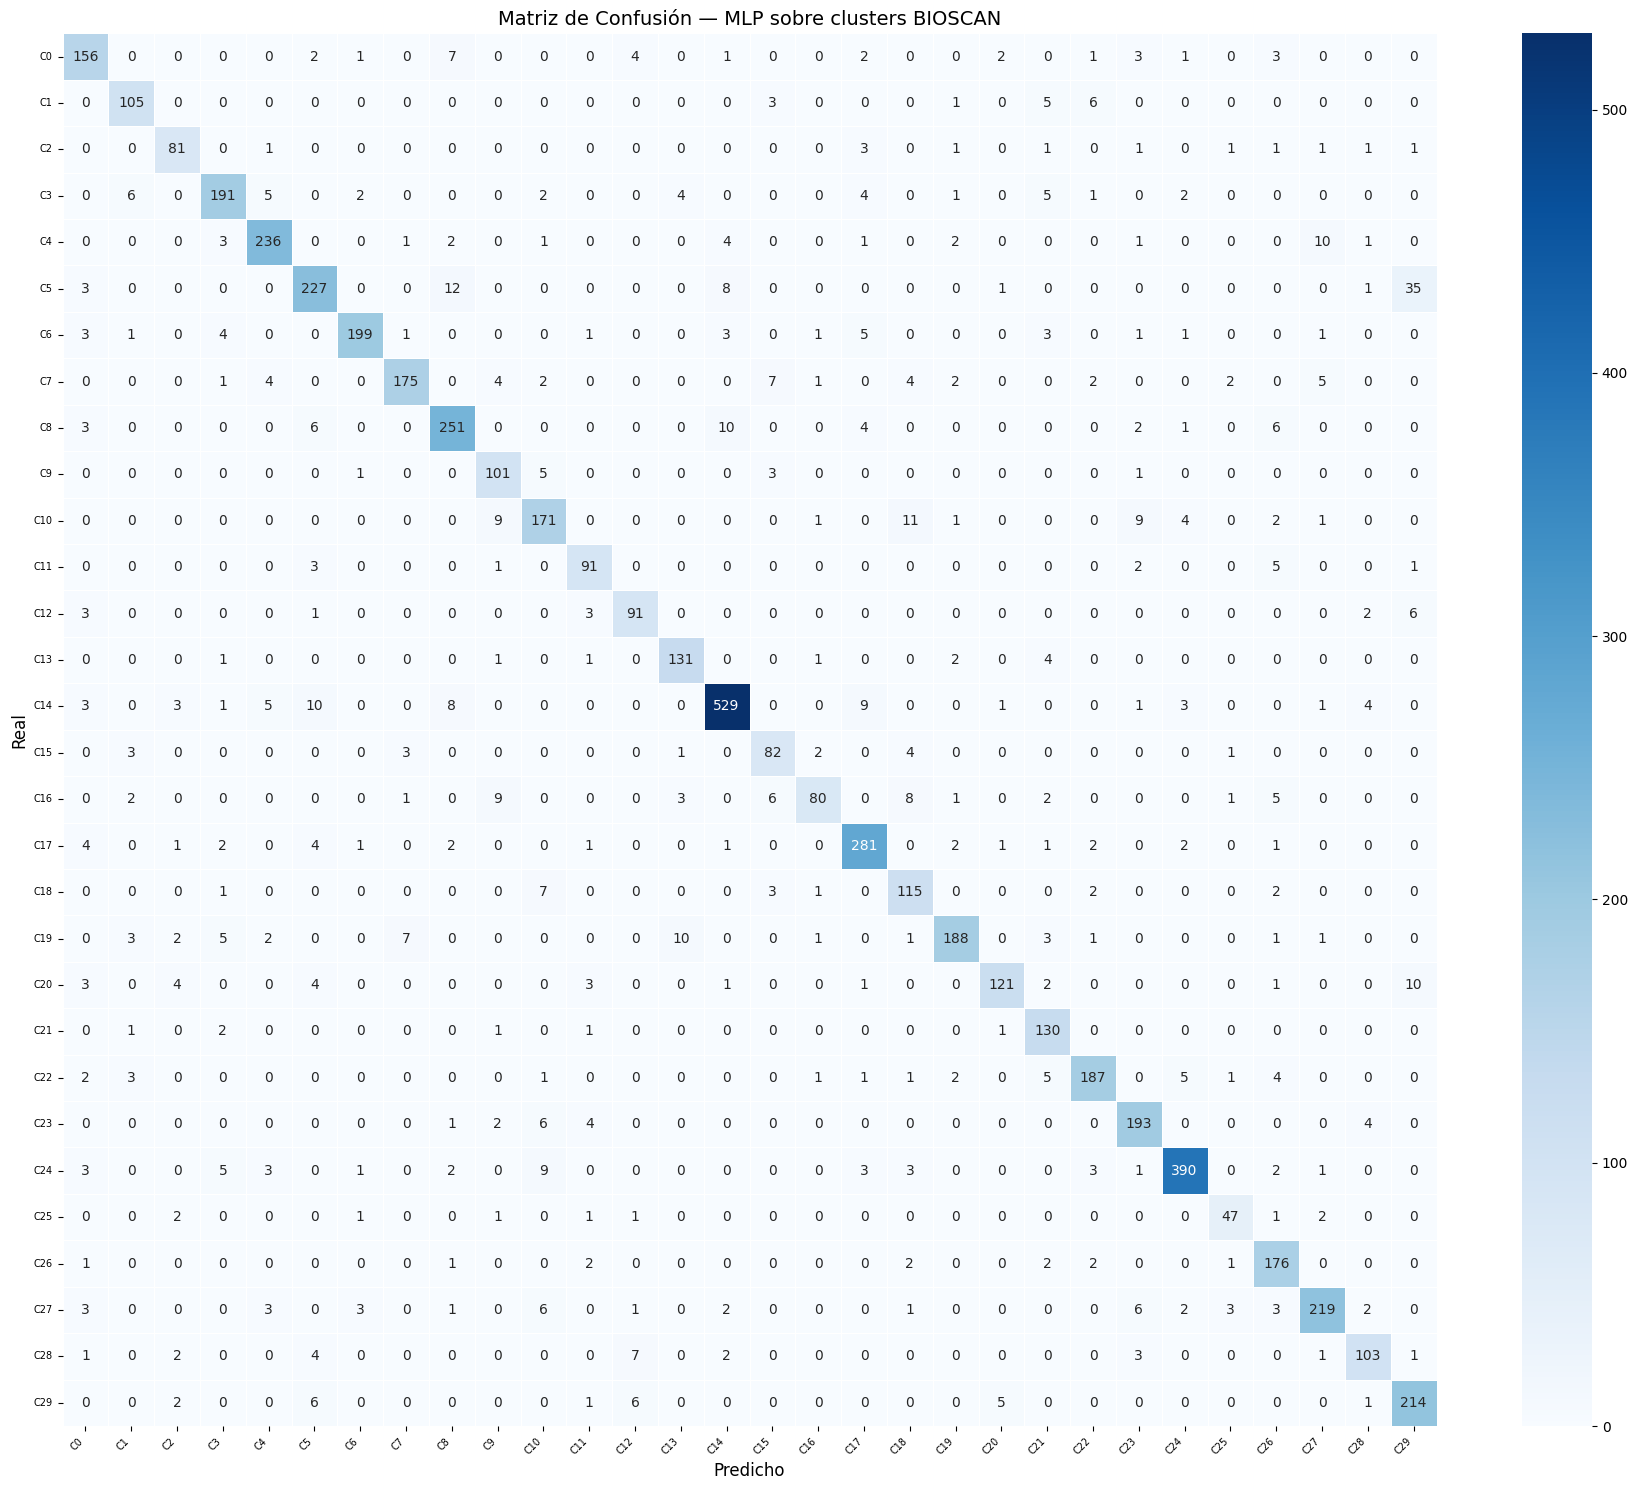

              precision    recall  f1-score   support

   Cluster 0       0.83      0.85      0.84       183
   Cluster 1       0.85      0.88      0.86       120
   Cluster 2       0.84      0.87      0.85        93
   Cluster 3       0.88      0.86      0.87       223
   Cluster 4       0.91      0.90      0.91       262
   Cluster 5       0.85      0.79      0.82       287
   Cluster 6       0.95      0.89      0.92       224
   Cluster 7       0.93      0.84      0.88       209
   Cluster 8       0.87      0.89      0.88       283
   Cluster 9       0.78      0.91      0.84       111
  Cluster 10       0.81      0.82      0.82       209
  Cluster 11       0.83      0.88      0.86       103
  Cluster 12       0.83      0.86      0.84       106
  Cluster 13       0.88      0.93      0.90       141
  Cluster 14       0.94      0.92      0.93       578
  Cluster 15       0.79      0.85      0.82        96
  Cluster 16       0.90      0.68      0.77       118
  Cluster 17       0.89    

In [83]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# ── Recolectar predicciones y etiquetas reales ────────────────
modelo.eval()
y_pred_all = []
y_true_all = []

with torch.no_grad():
    for block, _ in tqdm(load_images_in_blocks(test_paths, img_size=(64,64), block_size=1000),
                         total=len(test_paths)//1000 + 1, desc="Generando predicciones"):

        block_pca      = ipca.transform(block)
        X_batch        = torch.tensor(block_pca, dtype=torch.float32).to(device)

        # Etiquetas propagadas para test
        labels_cluster = minibatch_kmeans.predict(block_pca)
        y_batch        = np.array([y_representative[l] for l in labels_cluster])

        salida         = modelo(X_batch)
        prediccion     = torch.argmax(salida, dim=1).cpu().numpy()

        y_pred_all.extend(prediccion)
        y_true_all.extend(y_batch)

y_pred_all = np.array(y_pred_all)
y_true_all = np.array(y_true_all)

# ── Calcular matriz de confusión ──────────────────────────────
cm = confusion_matrix(y_true_all, y_pred_all)

# ── Visualizar ────────────────────────────────────────────────
plt.figure(figsize=(18, 15))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f"C{i}" for i in range(k)],
    yticklabels=[f"C{i}" for i in range(k)],
    linewidths=0.5
)
plt.title("Matriz de Confusión — MLP sobre clusters BIOSCAN", fontsize=14)
plt.xlabel("Predicho", fontsize=12)
plt.ylabel("Real", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# ── Métricas adicionales ──────────────────────────────────────
from sklearn.metrics import classification_report

print(classification_report(
    y_true_all,
    y_pred_all,
    target_names=[f"Cluster {i}" for i in range(k)]
))

## Aprendizaje Activo

In [84]:
# Probabilidades por imagen

modelo.eval()

all_probas  = []
all_indices = []

with torch.no_grad():
    for bloque_idx, (block, _) in enumerate(
        tqdm(load_images_in_blocks(train_paths, img_size=(64,64), block_size=1000),
             total=len(train_paths)//1000 + 1, desc="Calculando probabilidades")):

        block_pca = ipca.transform(block)
        X_batch   = torch.tensor(block_pca, dtype=torch.float32).to(device)

        salida    = modelo(X_batch)
        probas    = torch.softmax(salida, dim=1).cpu().numpy()  # (n, 30)

        all_probas.append(probas)
        inicio = bloque_idx * 1000
        all_indices.extend(range(inicio, inicio + len(block)))

all_probas = np.vstack(all_probas)  # (n_total, 30)
print(f"Shape probabilidades: {all_probas.shape}")

Calculando probabilidades:   4%|▍         | 1/25 [00:01<00:40,  1.67s/it]

  Bloque cargado: [0 - 1000]


Calculando probabilidades:   8%|▊         | 2/25 [00:03<00:38,  1.66s/it]

  Bloque cargado: [1000 - 2000]


Calculando probabilidades:  12%|█▏        | 3/25 [00:04<00:36,  1.65s/it]

...

  Bloque cargado: [21000 - 22000]


Calculando probabilidades:  92%|█████████▏| 23/25 [03:20<00:43, 21.88s/it]

  Bloque cargado: [22000 - 23000]


Calculando probabilidades:  96%|█████████▌| 24/25 [03:41<00:09,  9.23s/it]

  Bloque cargado: [23000 - 24000]
Shape probabilidades: (24000, 30)


In [85]:
# Probabilidad máxima de cada imagen (confianza del modelo)
max_probas  = np.max(all_probas, axis=1)   # (n_total,)

# Ordenar de MENOR a MAYOR confianza
sorted_ixs  = np.argsort(max_probas)       # los primeros = más inciertos

# Ver qué tan inseguros está en los peores casos
n_revisar = 30  # revisar 30 imágenes (1 por cluster)
print(f"Confianzas más bajas:")
print(max_probas[sorted_ixs[:n_revisar]])

Confianzas más bajas:
[0.22956817 0.2513476  0.27184942 0.28955573 0.29467842 0.29646486
 0.29820248 0.30423313 0.30646715 0.3073942  0.30791262 0.30839095
 0.30961052 0.31446594 0.31610656 0.31722003 0.31970936 0.32116148
 0.32414076 0.3269003  0.33046564 0.33230186 0.33269206 0.33469617
 0.33556387 0.33644956 0.33706507 0.3384957  0.34170902 0.34502828]


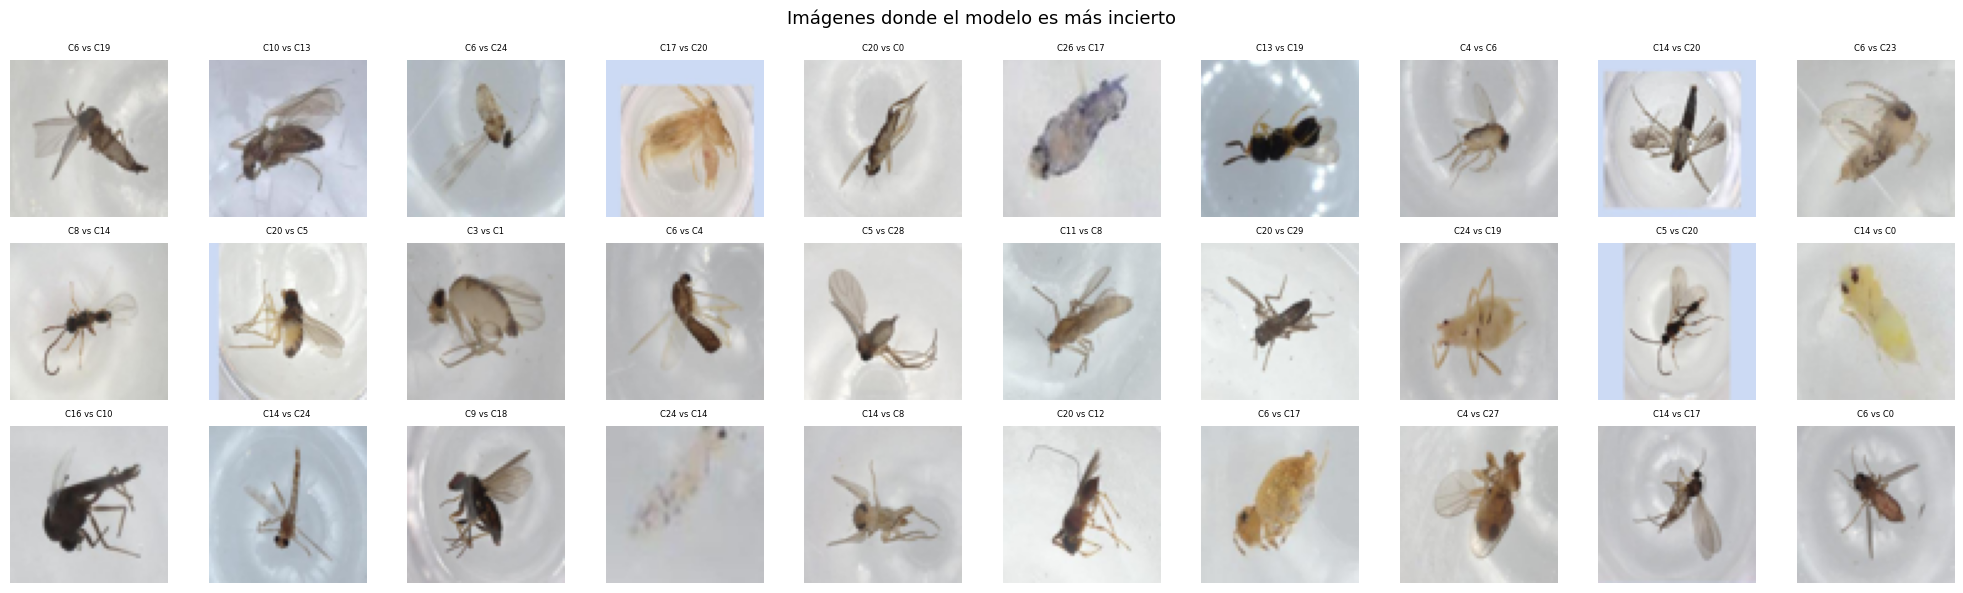

In [86]:
# Cargar y mostrar las n_revisar imágenes donde el modelo duda más
imgs_inciertas = []
for idx in sorted_ixs[:n_revisar]:
    path = train_paths[idx]
    img  = Image.open(path).convert('RGB').resize((64, 64))
    imgs_inciertas.append(np.array(img))

plt.figure(figsize=(20, 6))
for i, img in enumerate(imgs_inciertas):
    ax = plt.subplot(3, 10, i + 1)
    plt.imshow(img)

    # Mostrar las 2 clases más probables
    top2 = np.argsort(all_probas[sorted_ixs[i]])[-2:][::-1]
    plt.title(f"C{top2[0]} vs C{top2[1]}", fontsize=6)
    plt.axis('off')

plt.suptitle("Imágenes donde el modelo es más incierto", fontsize=13)
plt.tight_layout()
plt.show()

In [87]:
# Miras las imágenes del bloque anterior y corriges las etiquetas
# Ejemplo: si ves que la imagen 3 es claramente cluster 14, lo corriges

# Etiquetas actuales de las imágenes inciertas
etiquetas_actuales = y_train_propagated[sorted_ixs[:n_revisar]]
print(f"Etiquetas actuales: {etiquetas_actuales}")

# ── Corriges manualmente las que estén mal ──
# Formato: {posicion_en_sorted_ixs: etiqueta_correcta}
correcciones = {
    # Ejemplo:
    # 0: 14,   # imagen 0 es en realidad cluster 14
    # 5: 7,    # imagen 5 es en realidad cluster 7
}

# Aplicar correcciones
y_train_activo = y_train_propagated.copy()
for pos, etiqueta_correcta in correcciones.items():
    idx_real = sorted_ixs[pos]
    y_train_activo[idx_real] = etiqueta_correcta

print(f"Correcciones aplicadas: {len(correcciones)}")

Etiquetas actuales: [17 10  6 17  0 17 16  4 14  6 14  5  3  4 28  8 20 24  5 14 10 14 10 14
 14 20 17  4 14  0]
Correcciones aplicadas: 0


In [88]:
# Mismo MLP pero ahora con etiquetas corregidas
modelo_activo = MLP(input_dim=128, hidden1=256, hidden2=128, output_dim=k).to(device)

criterio_a    = nn.CrossEntropyLoss()
optimizador_a = optim.Adam(modelo_activo.parameters(), lr=0.001)
N_EPOCHS      = 20

modelo_activo.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0
    total_bloques = len(train_paths) // 1000 + 1

    for bloque_idx, (block, _) in enumerate(
        tqdm(load_images_in_blocks(train_paths, img_size=(64,64), block_size=1000),
             total=total_bloques, desc=f"Epoch {epoch+1}/{N_EPOCHS}", leave=False)):

        block_pca = ipca.transform(block)
        X_batch   = torch.tensor(block_pca, dtype=torch.float32).to(device)

        inicio  = bloque_idx * 1000
        fin     = inicio + len(block)
        y_batch = torch.tensor(
                      y_train_activo[inicio:fin],   # ← etiquetas corregidas
                      dtype=torch.long).to(device)

        optimizador_a.zero_grad()
        salida = modelo_activo(X_batch)
        loss   = criterio_a(salida, y_batch)
        loss.backward()
        optimizador_a.step()
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {epoch_loss/total_bloques:.4f}")

Epoch 1/20:   4%|▍         | 1/25 [00:14<05:49, 14.58s/it]

  Bloque cargado: [0 - 1000]


Epoch 1/20:   8%|▊         | 2/25 [00:28<05:26, 14.21s/it]

  Bloque cargado: [1000 - 2000]


Epoch 1/20:  12%|█▏        | 3/25 [00:41<04:57, 13.53s/it]

...

Epoch 20/20:  88%|████████▊ | 22/25 [00:26<00:03,  1.16s/it]

  Bloque cargado: [21000 - 22000]


Epoch 20/20:  92%|█████████▏| 23/25 [00:27<00:02,  1.16s/it]

  Bloque cargado: [22000 - 23000]


  Bloque cargado: [23000 - 24000]
Epoch 20 | Loss: 0.1067


In [89]:
# Evaluar modelo_activo igual que antes
modelo_activo.eval()
correctas = 0
total     = 0

with torch.no_grad():
    for block, _ in tqdm(load_images_in_blocks(test_paths, img_size=(64,64), block_size=1000),
                         total=len(test_paths)//1000 + 1, desc="Evaluando"):

        block_pca      = ipca.transform(block)
        X_batch        = torch.tensor(block_pca, dtype=torch.float32).to(device)
        labels_cluster = minibatch_kmeans.predict(block_pca)
        y_batch        = torch.tensor(
                             np.array([y_representative[l] for l in labels_cluster]),
                             dtype=torch.long).to(device)

        prediccion = torch.argmax(modelo_activo(X_batch), dim=1)
        correctas += (prediccion == y_batch).sum().item()
        total     += len(y_batch)

acc_activo = correctas / total * 100
print(f"Accuracy modelo propagado: 88.00%")
print(f"Accuracy modelo activo:    {acc_activo:.2f}%")
print(f"Mejora:                   +{acc_activo - 88.00:.2f}%")

Evaluando:  14%|█▍        | 1/7 [00:20<02:01, 20.23s/it]

  Bloque cargado: [0 - 1000]


Evaluando:  29%|██▊       | 2/7 [00:40<01:40, 20.15s/it]

  Bloque cargado: [1000 - 2000]


Evaluando:  43%|████▎     | 3/7 [00:59<01:19, 19.84s/it]

...

  Bloque cargado: [3000 - 4000]


Evaluando:  71%|███████▏  | 5/7 [01:36<00:37, 18.79s/it]

  Bloque cargado: [4000 - 5000]


Evaluando:  86%|████████▌ | 6/7 [01:53<00:18, 18.98s/it]

  Bloque cargado: [5000 - 6000]
Accuracy modelo propagado: 88.00%
Accuracy modelo activo:    88.52%
Mejora:                   +0.52%
